# **XAI4Spectra**

# **Loading data**

In [83]:
# importing the necessary libraries
import pandas as pd
import numpy as np
import kennard_stone as ks

# loading a soil spectral dataset based on X-ray fluorescence (XRF)
#data_complete = pd.read_csv('https://raw.githubusercontent.com/joseviniciusr/XAI4Spectra/main/XRFspectra.csv', sep=';') # Toledo 2022 dataset
data_complete = pd.read_csv('XRFspectra.csv', sep=';') # local copy of Toledo 2022 dataset
data = data_complete.loc[:, '1':'15']
data.insert(0, 'exCa', data_complete['exCa'])  # inserting the target variable (e.g., exCa (exchangeable calcium))

## **PLS- (R or DA) modeling**

In [84]:
def vip_scores(pls_model):
    """
    Calculate VIP (Variable Importance in Projection) scores for a fitted PLS model.
    Parameters
    ----------
    - **pls_model** : fitted PLS model object from sklearn.cross_decomposition.PLSRegression
        The PLS model for which to calculate VIP scores.
    Returns
    -------
    - vip_scores : ndarray, shape (n_features,)
        VIP scores for each feature in the model.
    """
    import numpy as np

    t = pls_model.x_scores_ # X scores 
    w = pls_model.x_weights_ # X weights
    p = pls_model.y_loadings_ # Y loadings
    features, _ = w.shape # number of features
    vip = np.zeros(shape=(features,)) # initializing VIP scores array
    inner_sum = np.diag(t.T @ t @ p.T @ p) # inner sum calculation
    SS_total = np.sum(inner_sum) # total sum of squares
    vip = np.sqrt(features*(w**2 @ inner_sum)/ SS_total) # VIP calculation
    return pd.DataFrame(vip)

def explained_variance_from_scores(X, T, P, Q=None, Y=None):
    """
    Calculate percent variance explained (based on PCTVAR Matlab function) for X and Y
    by using the scores T and loadings P (and optionally Q for Y).
    Parameters
    ----------
    - **X** : array-like, shape (n_samples, n_features)
        X matrix used in PLS.
    - **T** : array-like, shape (n_samples, n_components)
        Scores matrix from PLS.
    - **P** : array-like, shape (n_features, n_components)
        Loadings matrix for X from PLS.
    - **Q** : array-like, shape (n_targets, n_components), optional
        Loadings matrix for Y from PLS. Required if Yc is provided.
    - **Y** : array-like, shape (n_samples, n_targets), optional
       Y matrix used in PLS.
    Returns
    -------
    - result : dict with keys:
        - **'varX_cumulative'** : ndarray shape (n_components,)
            Percent cumulative variance of X explained by 1..j components.
        - **'varX_per_component'** : ndarray shape (n_components,)
            Percent variance of X explained per component.
        - **'varY_cumulative'** : ndarray shape (n_components,), or None
            Percent cumulative variance of Y explained by 1..j components (if Yc and Q provided).
        - **'varY_per_component'** : ndarray shape (n_components,), or None
            Percent variance of Y explained per component (if Yc and Q provided).
    """
    import numpy as np
    X = np.asarray(X, dtype=float) # X preprocessed data
    T = np.asarray(T, dtype=float) # scores
    P = np.asarray(P, dtype=float) # loadings for X

    n_comp = T.shape[1]
    TSS_X = np.sum(X ** 2) # total sum of squares of X
    if TSS_X == 0: # avoid division by zero
        raise ValueError("TSS_X == 0 (X does not have variability).")

    pctvarX_cum = np.zeros(n_comp, dtype=float) # cumulative percent variance for X

    for j in range(1, n_comp + 1): # loop over components
        Xhat_j = T[:, :j] @ P[:, :j].T # reconstructed X using j components
        SS_Xhat_j = np.sum(Xhat_j ** 2) # sum of squares of reconstructed X
        pctvarX_cum[j-1] = 100.0 * SS_Xhat_j / TSS_X # percent variance explained cumulativa
    
    # incremental (per component)
    pctvarX_per = np.empty_like(pctvarX_cum) # incremental percent variance for X
    pctvarX_per[0] = pctvarX_cum[0] # first component
    pctvarX_per[1:] = pctvarX_cum[1:] - pctvarX_cum[:-1] # rest

    # Y (if provided)
    pctvarY_cum = None # cumulative percent variance for Y
    pctvarY_per = None # incremental percent variance for Y
    if Q is not None and Y is not None: # if Y loadings and Y centered provided
        Q = np.asarray(Q, dtype=float) # loadings for Y
        Y = np.asarray(Y, dtype=float) # centered (and possibly scaled) Y
        TSS_Y = np.sum(Y ** 2) # total sum of squares of Y
        if TSS_Y == 0: # avoid division by zero
            pctvarY_cum = np.zeros(n_comp, dtype=float) # all zeros if Y has no variance
            pctvarY_per = np.zeros(n_comp, dtype=float) # all zeros
        else:
            pctvarY_cum = np.zeros(n_comp, dtype=float) # cumulative percent variance for Y
            for j in range(1, n_comp + 1): # loop over components
                Yhat_j = T[:, :j] @ Q[:, :j].T # reconstructed Y using j components
                SS_Yhat_j = np.sum(Yhat_j ** 2) # sum of squares of reconstructed Y
                pctvarY_cum[j-1] = 100.0 * SS_Yhat_j / TSS_Y # percent variance explained cumulativa
            pctvarY_per = np.empty_like(pctvarY_cum) # incremental percent variance for Y
            pctvarY_per[0] = pctvarY_cum[0] # first component
            pctvarY_per[1:] = pctvarY_cum[1:] - pctvarY_cum[:-1] # rest

        return {
            'varX_cumulative': pctvarX_cum[-1],
            'varX_per_component': pctvarX_per[-1],
            'varY_cumulative': pctvarY_cum[-1],
            'varY_per_component': pctvarY_per[-1]
            }         


def pls_optimized(Xcal, ycal, LVmax, Xpred=None, ypred=None, aim='regression', cv=10):
    """
    ## PLS optimized
    Function to fit a PLS regression or PLS-DA model with optimization of latent variables (LVs)
    using cross-validation. It calculates various performance metrics for calibration, cross-validation,
    and prediction (if provided) datasets
    **Parameters**:
    - **Xcal** : pd.DataFrame
        Calibration dataset features.
    - **ycal** : pd.Series or np.ndarray
        Calibration dataset target variable (regression) or binary class labels (classification).
    - **LVmax** : int
        Maximum number of latent variables to consider.
    - **Xpred** : pd.DataFrame, optional
        Prediction dataset features. Default is None.
    - **ypred** : pd.Series or np.ndarray, optional
        Prediction dataset target variable (regression) or binary class labels (classification). Default is None.
    - **aim** : str, optional
        Type of analysis: 'regression' for PLS regression or 'classification' for PLS-DA. Default is 'regression'.
    - **cv** : int, optional
        Number of cross-validation folds. Default is 10
        
    **Returns**:
    - **df_results** : pd.DataFrame
        DataFrame containing performance metrics for each number of latent variables.
    - **calres** : pd.DataFrame
        DataFrame containing predicted values for the calibration dataset.
    - **predres** : pd.DataFrame
        DataFrame containing predicted values for the prediction dataset (if provided).
    """

    import numpy as np
    import pandas as pd

    if aim == 'regression': # regression (PLSR)
        from sklearn.cross_decomposition import PLSRegression
        from sklearn.model_selection import cross_val_predict
        from sklearn.metrics import mean_squared_error, r2_score
        from scipy.stats import iqr

        results = [] # list to store results for each LV
        calres = pd.DataFrame(index=range(len(ycal))) # calibration results
        predres = pd.DataFrame(index=range(len(ypred))) if (Xpred is not None and ypred is not None) else None # prediction results

        for n_comp in range(1, LVmax + 1): # loop over number of components
            plsr = PLSRegression(n_components=n_comp, scale=False)
            plsr.fit(Xcal, ycal)
            y_cal = plsr.predict(Xcal).flatten()
            calres[f'LV_{n_comp}'] = y_cal

            y_cv = cross_val_predict(plsr, Xcal, ycal, cv=cv) # cross-validated predictions
            y_cv = np.array(y_cv).flatten()

            R2_cal = r2_score(ycal, y_cal) # determination coefficient
            r2_cal = np.corrcoef(ycal, y_cal)[0, 1] ** 2 # correlation coefficient squared
            rmse_cal = np.sqrt(mean_squared_error(ycal, y_cal))
            R2_cv = r2_score(ycal, y_cv)
            r2_cv = np.corrcoef(ycal, y_cv)[0, 1] ** 2
            rmsecv = np.sqrt(mean_squared_error(ycal, y_cv))
            rpd_cv = ycal.std() / rmsecv if rmsecv != 0 else np.nan
            rpiq_cv = iqr(ycal, rng=(25, 75)) / rmsecv if rmsecv != 0 else np.nan
            bias_cv = np.sum(ycal - y_cv) / ycal.shape[0]
            SDV_cv = (ycal - y_cv) - bias_cv
            SDV_cv = np.sqrt(np.sum(SDV_cv * SDV_cv) / (ycal.shape[0] - 1)) if ycal.shape[0] > 1 else np.nan
            tbias_cv = abs(bias_cv) * (np.sqrt(ycal.shape[0]) / SDV_cv) if SDV_cv not in (0, np.nan) else np.nan
            
            # explained variance
            exp_var = explained_variance_from_scores(Xcal, plsr.x_scores_, plsr.x_loadings_,
                                               Q=plsr.y_loadings_, Y=ycal) # explained variance
            
            # vip scores
            vip = vip_scores(plsr).T
            vip.columns = plsr.feature_names_in_ # setting feature names

            if Xpred is not None and ypred is not None: # prediction set
                y_pred = plsr.predict(Xpred).flatten()
                predres[f'LV_{n_comp}'] = y_pred

                R2_pred = r2_score(ypred, y_pred) # determination coefficient
                r2_pred = np.corrcoef(ypred, y_pred)[0, 1] ** 2 # correlation coefficient squared
                rmsep = np.sqrt(mean_squared_error(ypred, y_pred))
                rpd_pred = ypred.std() / rmsep if rmsep != 0 else np.nan
                rpiq_pred = iqr(ypred, rng=(25, 75)) / rmsep if rmsep != 0 else np.nan
                bias_pred = np.sum(ypred - y_pred) / ypred.shape[0]
                SDV_pred = (ypred - y_pred) - bias_pred
                SDV_pred = np.sqrt(np.sum(SDV_pred * SDV_pred) / (ypred.shape[0] - 1)) if ypred.shape[0] > 1 else np.nan
                tbias_pred = abs(bias_pred) * (np.sqrt(ypred.shape[0]) / SDV_pred) if SDV_pred not in (0, np.nan) else np.nan
            else:
                r2_pred = rmsep = rpd_pred = rpiq_pred = bias_pred = tbias_pred = None

            results.append({
                'LVs': n_comp,
                'R2_Cal': R2_cal,
                'r2_Cal': r2_cal,
                'RMSEC': rmse_cal,
                'R2_CV': R2_cv,
                'r2_Cv': r2_cv,
                'RMSECV': rmsecv,
                'RPD_CV': rpd_cv,
                'RPIQ_CV': rpiq_cv,
                'Bias_CV': bias_cv,
                'tbias_CV': tbias_cv,
                'R2_Pred': R2_pred,
                'r2_Pred': r2_pred,
                'RMSEP': rmsep,
                'RPD_Pred': rpd_pred,
                'RPIQ_Pred': rpiq_pred,
                'Bias_Pred': bias_pred,
                'tbias_Pred': tbias_pred,
                'X_Cum_Exp_Var' : exp_var['varX_cumulative'],
                'Y_Cum_Exp_Var' : exp_var['varY_cumulative'],
                'X_Ind_Exp_Var' : exp_var['varX_per_component'],
                'Y_Ind_Exp_Var' : exp_var['varY_per_component']
            })

        model = plsr  # last model fitted
        df_results = pd.DataFrame(results)
        calres.insert(0, 'Ref', np.array(ycal))
        if predres is not None:
            predres.insert(0, 'Ref', np.array(ypred))

    elif aim == 'classification': # classification (PLS-DA)
        from sklearn.cross_decomposition import PLSRegression
        from sklearn.model_selection import cross_val_predict
        from sklearn.metrics import accuracy_score, confusion_matrix

        results = []
        calres = pd.DataFrame(index=range(len(ycal))) # calibration results
        predres = pd.DataFrame(index=range(len(ypred))) if (Xpred is not None and ypred is not None) else None # prediction results

        # ensure binary classes
        ycal_series = pd.Series(ycal).reset_index(drop=True) # ensure it's a Series
        unique_labels = ycal_series.unique() # unique class labels
        if len(unique_labels) != 2: # check for binary classification
            raise ValueError(f"PLS-DA (this function) expects 2 classes (binary). Found: {unique_labels}")

        label_to_num = {lab: idx for idx, lab in enumerate(unique_labels)} # mapping labels to 0 and 1
        num_to_label = {idx: lab for lab, idx in label_to_num.items()} # reverse mapping for predictions
       
        # prepare ycal numeric
        ycal_numeric = np.array([label_to_num[i] for i in ycal]) 

        # prepare ypred numeric if provided
        ypred_numeric = None
        if ypred is not None:
            ypred_numeric = np.array([label_to_num[i] for i in ypred])

        for n_comp in range(1, LVmax + 1): # loop over number of components
            plsda = PLSRegression(n_components=n_comp, scale=False)
            plsda.fit(Xcal, ycal_numeric)

            # calibration continuous predictions -> binarize
            y_cal_cont = plsda.predict(Xcal).flatten()
            y_cal_bin = (y_cal_cont >= 0.5).astype(int)
            y_cal_class = np.array([num_to_label[i] for i in y_cal_bin])
            calres[f'LV_{n_comp}'] = y_cal_class
            calres_numeric = pd.DataFrame(y_cal_cont, columns=[f'LV_{n_comp}']) # numeric calibration results

            # cross-validated continuous predictions -> binarize
            y_cv_cont = cross_val_predict(plsda, Xcal, ycal_numeric, cv=cv)
            y_cv_cont = np.array(y_cv_cont).flatten()
            y_cv_bin = (y_cv_cont >= 0.5).astype(int)

            # metrics
            acc_cal = accuracy_score(ycal_numeric, y_cal_bin)
            cm_cal = confusion_matrix(ycal_numeric, y_cal_bin)
            # safe unpack for binary confusion matrix
            if cm_cal.size == 4:
                tn, fp, fn, tp = cm_cal.ravel()
            else:
                tn = fp = fn = tp = np.nan
            sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
            specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

            acc_cv = accuracy_score(ycal_numeric, y_cv_bin)
            cm_cv = confusion_matrix(ycal_numeric, y_cv_bin)
            if cm_cv.size == 4:
                tn_cv, fp_cv, fn_cv, tp_cv = cm_cv.ravel()
            else:
                tn_cv = fp_cv = fn_cv = tp_cv = np.nan
            sensitivity_cv = tp_cv / (tp_cv + fn_cv) if (tp_cv + fn_cv) > 0 else np.nan
            specificity_cv = tn_cv / (tn_cv + fp_cv) if (tn_cv + fp_cv) > 0 else np.nan

            # explained variance
            exp_var = explained_variance_from_scores(Xcal, plsda.x_scores_, plsda.x_loadings_,
                                               Q=plsda.y_loadings_, Y=ycal_numeric.reshape(-1, 1)) # explained variance

            # vip scores
            vip = vip_scores(plsda).T
            vip.columns = plsda.feature_names_in_ # setting feature names

            # prediction set (if provided)
            if Xpred is not None and ypred is not None:
                y_pred_cont = plsda.predict(Xpred).flatten()
                y_pred_bin = (y_pred_cont >= 0.5).astype(int)
                y_pred_class = np.array([num_to_label[i] for i in y_pred_bin])
                predres[f'LV_{n_comp}'] = y_pred_class
                predres_numeric = pd.DataFrame(y_pred_cont, columns=[f'LV_{n_comp}']) # numeric prediction results

                acc_pred = accuracy_score(ypred_numeric, y_pred_bin)
                cm_pred = confusion_matrix(ypred_numeric, y_pred_bin)
                if cm_pred.size == 4:
                    tn_p, fp_p, fn_p, tp_p = cm_pred.ravel()
                else:
                    tn_p = fp_p = fn_p = tp_p = np.nan
                sensitivity_p = tp_p / (tp_p + fn_p) if (tp_p + fn_p) > 0 else np.nan
                specificity_p = tn_p / (tn_p + fp_p) if (tn_p + fp_p) > 0 else np.nan
            else:
                acc_pred = sensitivity_p = specificity_p = cm_pred = tn_p = fp_p = fn_p = tp_p = None

            results.append({
                'LVs': n_comp,
                'Accuracy Cal': acc_cal,
                'Sensitivity Cal': sensitivity,
                'Specificity Cal': specificity,
                'CM Cal': cm_cal,
                'Accuracy CV': acc_cv,
                'Sensitivity CV': sensitivity_cv,
                'Specificity CV': specificity_cv,
                'CM CV': cm_cv,
                'Accuracy Pred': acc_pred,
                'Sensitivity Pred': sensitivity_p,
                'Specificity Pred': specificity_p,
                'CM Pred': cm_pred,
                'X Cum Exp Var' : exp_var['varX_cumulative'],
                'Y Cum Exp Var' : exp_var['varY_cumulative'],
                'X Ind Exp Var' : exp_var['varX_per_component'],
                'Y Ind Exp Var' : exp_var['varY_per_component']
            })

        model = plsda  # last model fitted
        df_results = pd.DataFrame(results)
        calres.insert(0, 'Ref', np.array(ycal))
        if predres is not None:
            predres.insert(0, 'Ref', np.array(ypred))

    else:
        raise ValueError("Parameter `aim` must be 'regression' or 'classification'.")

    return df_results, calres, predres, model, vip, calres_numeric, predres_numeric

In [85]:
def extract_spectral_zones(Xcal, cuts):
    """
    Extract spectral zones from a DataFrame based on specified cuts.
    
    Parameters
    ----------
    - **Xcal** : pd.DataFrame
        DataFrame with spectral data, where columns are wavelengths/energies.
    - **cuts** : list of tuples/lists or dicts
        Each item defines a spectral zone to extract.
        - If tuple/list: (start, end) or (name, start, end)
        - If dict: {'name': str, 'start': float, 'end': float}
    
    Returns
    -------
    - **zones** : dict
        Dictionary where keys are zone names and values are DataFrames with the extracted spectral zones.
    """
    import numpy as np
    import pandas as pd

    # convert the column names to numeric when possible (NaN when not convertible)
    col_nums = pd.to_numeric(Xcal.columns.astype(str), errors='coerce')
    zones = {} # dictionary to store extracted zones

    for cut in cuts:
        # normalize cut format
        if isinstance(cut, dict): # if dict
            name = cut.get('name', f"{cut.get('start')}-{cut.get('end')}") # default name if not provided
            start = cut.get('start') # getting start value
            end = cut.get('end') # getting end value
        elif isinstance(cut, (list, tuple)): # if list/tuple
            if len(cut) == 2: 
                start, end = cut # getting start and end values
                name = f"{start}-{end}" # default name
            elif len(cut) == 3: # if name provided
                name, start, end = cut # getting name, start and end values
            else:
                raise ValueError("Cuts in tuple/list format must have 2 or 3 elements.")
        else:
            raise ValueError("Each cut must be a dict or a tuple/list.")

        # validate start and end
        try:
            s = float(start)
            e = float(end)
        except Exception: # Exception for conversion errors
            raise ValueError("star and end must be numeric values (int/float or convertible strings).")

        if s > e: # swap if necessary
            s, e = e, s

        # to select columns whose numeric value is in the interval [s, e]
        mask = (~np.isnan(col_nums)) & (col_nums >= s) & (col_nums <= e)
        selected_cols = list(Xcal.columns[mask])

        # piecing the zone DataFrame into the dictionary
        zones[name] = Xcal.loc[:, selected_cols]

    return zones

# **Classification case**

In [86]:
# Creating a new column 'Class' based on the condition of 'BSP' values
data_complete['Class'] = np.where(data_complete['BSP'] > 50.00, 'eut', 'dist') # eutrophic (eut) if BSP > 50.00 (higher fertility), otherwise dystrophic (dist)
data_eut = data_complete[data_complete['Class'] == 'eut'].reset_index(drop=True)
data_dist = data_complete[data_complete['Class'] == 'dist'].reset_index(drop=True)

In [87]:
# splitting the data into calibration and prediction sets by kennard-stone algorithm
Xeut_cal, Xeut_pred = ks.train_test_split(data_eut.loc[:, '1':'15'], test_size=0.30) # class eutrophic
Xeut_cal = Xeut_cal.reset_index(drop=True)
Xeut_pred = Xeut_pred.reset_index(drop=True)

Xdist_cal, Xdist_pred = ks.train_test_split(data_dist.loc[:, '1':'15'], test_size=0.30) # class dystrophic
Xdist_cal = Xdist_cal.reset_index(drop=True)
Xdist_pred = Xdist_pred.reset_index(drop=True)

Xcalclass = pd.concat([Xeut_cal, Xdist_cal], axis=0).reset_index(drop=True) # concatenating both classes
Xpredclass = pd.concat([Xeut_pred, Xdist_pred], axis=0).reset_index(drop=True)
ycalclass = pd.Series(['eut']*Xeut_cal.shape[0] + ['dist']*Xdist_cal.shape[0]) # creating the target variable for calibration set
ypredclass = pd.Series(['eut']*Xeut_pred.shape[0] + ['dist']*Xdist_pred.shape[0]) # creating the target variable for prediction set

C:\Users\Usuario\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

2025-12-02 10:32:44,948 - kennard_stone.utils._pairwise:109[INFO] - Calculating pairwise distances using scikit-learn.

C:\Users\Usuario\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

2025-12-02 10:32:44,963 - kennard_stone.utils._pairwise:109[INFO] - Calculating pairwise distances using scikit-learn.

C:\Users\Usuario\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

C:\Users\Usuario\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 

In [88]:
pd.options.plotting.backend = 'plotly' # setting plotly as the backend for pandas plotting 
Xcalclass.T.plot() # easily plotting the spectra 

In [89]:
# preprocessings
import preprocessings as prepr # preprocessing methods for XRF data

Xcalclass_prep, mean_calclass, mean_calclass_poisson  = prepr.poisson(Xcalclass, mc=True)
Xpredclass_prep = ((Xpredclass/np.sqrt(mean_calclass)) - mean_calclass_poisson)

In [90]:
# performing PLS-DA with optimized latent variables
plsda_results = pls_optimized(Xcalclass_prep, 
                              ycalclass,
                              LVmax=4,
                              Xpred=Xpredclass_prep,
                              ypred=ypredclass,
                              aim='classification',
                              cv=10)
plsda_results[0]

,LVs,Accuracy Cal,Sensitivity Cal,Specificity Cal,CM Cal,Accuracy CV,Sensitivity CV,Specificity CV,CM CV,Accuracy Pred,Sensitivity Pred,Specificity Pred,CM Pred,X Cum Exp Var,Y Cum Exp Var,X Ind Exp Var,Y Ind Exp Var
0,1,0.804054,0.845070,0.766234,"[[59, 18], [11, 60]]",0.722973,0.746479,0.701299,"[[54, 23], [18, 53]]",0.750000,0.870968,0.636364,"[[21, 12], [4, 27]]",24.084452,18.486320,24.084452,18.486320
1,2,0.851351,0.915493,0.792208,"[[61, 16], [6, 65]]",0.810811,0.873239,0.753247,"[[58, 19], [9, 62]]",0.843750,0.967742,0.727273,"[[24, 9], [1, 30]]",46.025807,20.883518,21.941354,2.397198
2,3,0.831081,0.901408,0.766234,"[[59, 18], [7, 64]]",0.797297,0.845070,0.753247,"[[58, 19], [11, 60]]",0.828125,0.967742,0.696970,"[[23, 10], [1, 30]]",70.291459,21.960174,24.265653,1.076656
3,4,0.871622,0.887324,0.857143,"[[66, 11], [8, 63]]",0.770270,0.845070,0.701299,"[[54, 23], [11, 60]]",0.875000,0.967742,0.787879,"[[26, 7], [1, 30]]",78.655943,24.395837,8.364483,2.435663


In [91]:
# establishing spectral cuts based on expert knowledge of XRF spectra
spectral_cuts = [
('Al', 1.34, 1.63),
('Si', 1.64, 1.86),
('P', 1.94, 2.10),
('S', 2.20, 2.44),
('Rh L + Ar', 2.56, 3.10),
('K', 3.22, 3.42),
('Ca ka', 3.54, 3.82),
('Ca kb', 3.92, 4.14),
('Ti ka', 4.38, 4.66),
('Ti kb', 4.76, 5.12),
('Cr', 5.13, 5.77),
('Mn', 5.78, 6.02),
('Fe ka', 6.14, 6.68),
('Fe kb', 6.81, 7.30),
('Cu', 7.92, 8.20),
('Fe ka + Ti ka', 10.7, 11.14),
('sum Fe' , 12.56, 13.1),
]

In [92]:
spectral_zones_class = extract_spectral_zones(Xcalclass, spectral_cuts) # extracting the spectral zones
spectral_zones_class['Fe ka + Ti ka'].T.plot(title='spectral zone') # plotting the Al ka spectral zone

# **Extracting predicates - plsda case**

In [93]:
# calculating the median for each spectral zone DataFram with respect to the variables (columns)
zone_sums_df = pd.DataFrame({
    zone: df.sum(axis=1) for zone, df in spectral_zones_class.items()
})
zone_sums_df

,Al,Si,P,S,Rh L + Ar,K,Ca ka,Ca kb,Ti ka,Ti kb,Cr,Mn,Fe ka,Fe kb,Cu,Fe ka + Ti ka,sum Fe
0,27.140,88.340,3.580,7.065,149.635,17.040,35.645,14.435,477.695,119.400,57.705,52.395,4206.615,672.985,17.270,17.665,31.570
1,31.650,83.060,3.805,7.100,153.020,18.040,38.250,14.955,422.605,107.865,57.920,42.630,4000.315,639.965,17.100,17.800,29.650
2,28.905,88.685,2.895,6.240,151.535,13.980,26.680,13.315,463.815,116.715,58.005,46.350,4223.315,674.000,17.140,17.815,31.545
3,30.260,81.205,3.275,7.115,152.310,13.790,32.220,14.345,507.425,125.785,58.870,50.295,4392.400,702.445,16.830,18.615,32.830
4,32.650,93.030,3.050,6.500,154.015,15.965,23.455,12.750,458.270,114.750,59.180,47.575,4222.200,674.620,17.420,18.450,31.270
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143,32.800,78.740,3.465,7.085,149.690,13.920,21.620,13.100,331.045,96.025,66.620,56.675,4632.705,734.765,17.155,17.125,36.385
144,30.960,78.520,5.280,6.980,151.950,15.140,24.940,13.410,461.720,117.570,59.440,44.940,4329.930,691.060,16.990,19.810,34.280
145,32.770,76.400,3.150,6.390,153.370,14.160,14.870,12.220,475.230,120.110,59.280,44.100,4411.650,702.360,16.810,19.250,34.640
146,28.300,67.545,3.005,6.340,145.455,13.730,18.915,11.440,393.480,101.690,54.460,37.275,3923.505,631.615,15.935,16.610,28.185


In [94]:
def predicates_by_quantiles(zone_sums_df, quantiles):
    """
    Generate predicates based on specified quantiles for each column in a DataFrame
    and create a predicate indicator matrix.
    
    Parameters
    ----------
    - **zone_sums_df** : pd.DataFrame
        DataFrame with summed values for spectral zones.
    - **quantiles** : list of float
        List of quantiles (between 0 and 1) to generate predicates for.
    
    Returns
    -------
    - **predicates_df** : pd.DataFrame
        DataFrame containing the generated predicates with columns:
        'predicate', 'rule', 'zone', 'thresholds', 'operator'.
    - **predicate_indicator_df** : pd.DataFrame
        Binary indicator matrix (samples × predicates) where 1 indicates
        the sample satisfies the predicate, 0 otherwise.
    """
    import pandas as pd
    import numpy as np

    # calculating the quantiles for each column of zone_sums_df
    zone_quantiles = zone_sums_df.quantile(quantiles)
    
    zone_predicate_list = []
    predicate_num = 1
    for zone in zone_sums_df.columns:
        for q in quantiles:
            q_value = zone_quantiles.loc[q, zone]
            # <= Q
            zone_predicate_list.append({
                'predicate': f'P{predicate_num}',
                'rule': f"{zone} <= {q_value:.2f}",
                'zone': zone,
                'thresholds': f"{q_value:.2f}",
                'operator': "<="
            })
            predicate_num += 1
            # > Q
            zone_predicate_list.append({
                'predicate': f'P{predicate_num}',
                'rule': f"{zone} > {q_value:.2f}",
                'zone': zone,
                'thresholds': f"{q_value:.2f}",
                'operator': ">"
            })
            predicate_num += 1
    
    predicates_df = pd.DataFrame(zone_predicate_list)
    
    # Generating the predicate indicator DataFrame
    
    # function to evaluate a predicate for a given value
    def eval_predicate(value, thresholds, operator):
        if operator == "<=":
            return float(value <= float(thresholds))
        elif operator == ">":
            return float(value > float(thresholds))
        else:
            return np.nan
    
    # initializing empty DataFrame
    predicate_indicator_df = pd.DataFrame(index=zone_sums_df.index)
    
    # iterating over each predicate
    for _, row in predicates_df.iterrows():
        pred = row['predicate']
        zone = row['zone']
        thresholds = row['thresholds']
        operator = row['operator']
        predicate_indicator_df[pred] = zone_sums_df[zone].apply(
            lambda v: eval_predicate(v, thresholds, operator)
        ).astype(int)
    
    # setting column names to rules for better readability
    predicate_indicator_df.columns = predicates_df['rule'].tolist()
    
    # computing co-occurrence matrix
    co_occurrence_matrix = np.dot(predicate_indicator_df.T, predicate_indicator_df)
    co_occurrence_matrix_df = pd.DataFrame(co_occurrence_matrix, index=predicate_indicator_df.columns, columns=predicate_indicator_df.columns) 

    return predicates_df, predicate_indicator_df, co_occurrence_matrix_df

In [95]:
predicates_quantiles = predicates_by_quantiles(zone_sums_df, [0.2, 0.4, 0.6, 0.8]) # getting predicates for quartiles
predicates_quantiles[0]

C:\Users\Usuario\AppData\Local\Temp\ipykernel_29708\3711397534.py:74: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

C:\Users\Usuario\AppData\Local\Temp\ipykernel_29708\3711397534.py:74: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

C:\Users\Usuario\AppData\Local\Temp\ipykernel_29708\3711397534.py:74: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fr

,predicate,rule,zone,thresholds,operator
0,P1,Al <= 30.77,Al,30.77,<=
1,P2,Al > 30.77,Al,30.77,>
2,P3,Al <= 32.23,Al,32.23,<=
3,P4,Al > 32.23,Al,32.23,>
4,P5,Al <= 33.67,Al,33.67,<=
...,...,...,...,...,...
131,P132,sum Fe > 32.13,sum Fe,32.13,>
132,P133,sum Fe <= 33.21,sum Fe,33.21,<=
133,P134,sum Fe > 33.21,sum Fe,33.21,>
134,P135,sum Fe <= 34.13,sum Fe,34.13,<=


In [96]:
predicates_quantiles[1] # predicate indicator DataFrame

,Al <= 30.77,Al > 30.77,Al <= 32.23,Al > 32.23,Al <= 33.67,Al > 33.67,Al <= 34.78,Al > 34.78,Si <= 73.63,Si > 73.63,...,Fe ka + Ti ka <= 18.85,Fe ka + Ti ka > 18.85,sum Fe <= 30.71,sum Fe > 30.71,sum Fe <= 32.13,sum Fe > 32.13,sum Fe <= 33.21,sum Fe > 33.21,sum Fe <= 34.13,sum Fe > 34.13
0,1,0,1,0,1,0,1,0,0,1,...,1,0,0,1,1,0,1,0,1,0
1,0,1,1,0,1,0,1,0,0,1,...,1,0,1,0,1,0,1,0,1,0
2,1,0,1,0,1,0,1,0,0,1,...,1,0,0,1,1,0,1,0,1,0
3,1,0,1,0,1,0,1,0,0,1,...,1,0,0,1,0,1,1,0,1,0
4,0,1,0,1,1,0,1,0,0,1,...,1,0,0,1,1,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143,0,1,0,1,1,0,1,0,0,1,...,1,0,0,1,0,1,0,1,0,1
144,0,1,1,0,1,0,1,0,0,1,...,0,1,0,1,0,1,0,1,0,1
145,0,1,0,1,1,0,1,0,0,1,...,0,1,0,1,0,1,0,1,0,1
146,1,0,1,0,1,0,1,0,1,0,...,1,0,1,0,1,0,1,0,1,0


In [97]:
# co-ocurrence matrix
co_occurrence_matrix_df=predicates_quantiles[2]
co_occurrence_matrix_df
## the co-occurrence matrix indicates how many samples satisfy each pair of predicates
## for example, if P1 and P2 co-occur in 10 samples, the value at (P1, P2) and (P2, P1) will be 10
## the principal diagonal indicates how many samples satisfy each individual predicate
## while the off-diagonal elements indicate co-occurrence counts

,Al <= 30.77,Al > 30.77,Al <= 32.23,Al > 32.23,Al <= 33.67,Al > 33.67,Al <= 34.78,Al > 34.78,Si <= 73.63,Si > 73.63,...,Fe ka + Ti ka <= 18.85,Fe ka + Ti ka > 18.85,sum Fe <= 30.71,sum Fe > 30.71,sum Fe <= 32.13,sum Fe > 32.13,sum Fe <= 33.21,sum Fe > 33.21,sum Fe <= 34.13,sum Fe > 34.13
Al <= 30.77,30,0,30,0,30,0,30,0,7,23,...,25,5,10,20,21,9,28,2,29,1
Al > 30.77,0,118,29,89,60,58,88,30,23,95,...,93,25,20,98,38,80,63,55,89,29
Al <= 32.23,30,29,59,0,59,0,59,0,17,42,...,51,8,21,38,35,24,47,12,53,6
Al > 32.23,0,89,0,89,31,58,59,30,13,76,...,67,22,9,80,24,65,44,45,65,24
Al <= 33.67,30,60,59,31,90,0,90,0,24,66,...,73,17,23,67,47,43,64,26,75,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
sum Fe > 32.13,9,80,24,65,43,46,62,27,17,72,...,63,26,0,89,0,89,32,57,59,30
sum Fe <= 33.21,28,63,47,44,64,27,78,13,20,71,...,83,8,30,61,59,32,91,0,91,0
sum Fe > 33.21,2,55,12,45,26,31,40,17,10,47,...,35,22,0,57,0,57,0,57,27,30
sum Fe <= 34.13,29,89,53,65,75,43,98,20,22,96,...,101,17,30,88,59,59,91,27,118,0


In [98]:
# inserting the assigned class based on the model predictions to the predicate indicator DataFrame
predicates_quantiles[1].insert(0, 'Class_predicted', plsda_results[1].iloc[:, -1]) # inserting the predicted class from plsda_results
predicates_quantiles[1]

C:\Users\Usuario\AppData\Local\Temp\ipykernel_29708\499801049.py:2: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



,Class_predicted,Al <= 30.77,Al > 30.77,Al <= 32.23,Al > 32.23,Al <= 33.67,Al > 33.67,Al <= 34.78,Al > 34.78,Si <= 73.63,...,Fe ka + Ti ka <= 18.85,Fe ka + Ti ka > 18.85,sum Fe <= 30.71,sum Fe > 30.71,sum Fe <= 32.13,sum Fe > 32.13,sum Fe <= 33.21,sum Fe > 33.21,sum Fe <= 34.13,sum Fe > 34.13
0,eut,1,0,1,0,1,0,1,0,0,...,1,0,0,1,1,0,1,0,1,0
1,eut,0,1,1,0,1,0,1,0,0,...,1,0,1,0,1,0,1,0,1,0
2,eut,1,0,1,0,1,0,1,0,0,...,1,0,0,1,1,0,1,0,1,0
3,eut,1,0,1,0,1,0,1,0,0,...,1,0,0,1,0,1,1,0,1,0
4,eut,0,1,0,1,1,0,1,0,0,...,1,0,0,1,1,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143,eut,0,1,0,1,1,0,1,0,0,...,1,0,0,1,0,1,0,1,0,1
144,dist,0,1,1,0,1,0,1,0,0,...,0,1,0,1,0,1,0,1,0,1
145,dist,0,1,0,1,1,0,1,0,0,...,0,1,0,1,0,1,0,1,0,1
146,dist,1,0,1,0,1,0,1,0,1,...,1,0,1,0,1,0,1,0,1,0


In [99]:
predicate_info_dict = {}
for _, row in predicates_quantiles[0].iterrows(): # o iterrows retorna o indice e a linha do dataframe (a linha contem os dados que podem ser acessados por nome de coluna)
    pred = row['rule'] # capturando o nome do predicado (regra)
    # selecionando as amostras que satisfazem o predicado (valor 1 na coluna do predicado)
    satisfied_samples = zone_sums_df.index[predicates_quantiles[1][pred] == 1].tolist() # o == 1 indica que a amostra satisfaz o predicado (valor 1 na coluna do predicado)
    if satisfied_samples: # apenas se houver amostras que satisfazem o predicado
        # criando o dataframe com as informacoes
        df_info = pd.DataFrame({
            'Zone_Sum': zone_sums_df.loc[satisfied_samples, row['zone']].reset_index(drop=True), # a zona correspondente ao predicado 
            # a lista satisfied_samples foi gerada contendo os indices das amostras que satisfazem o predicado
            'Predicted_Y': plsda_results[5].iloc[satisfied_samples, -1].reset_index(drop=True) # os valores preditos pelo modelo para essas amostras
        })
        predicate_info_dict[pred] = df_info

In [100]:
print(f'informacoes do primeiro predicado do dicionario: {list(predicate_info_dict.keys())[0]}')
predicate_info_dict[list(predicate_info_dict.keys())[0]] # exibindo as informacoes do primeiro predicado do dicionario

informacoes do primeiro predicado do dicionario: Al <= 30.77


,Zone_Sum,Predicted_Y
0,27.140,0.007734
1,28.905,0.304601
2,30.260,0.298230
3,29.350,-0.030014
4,28.265,-0.131567
5,28.730,0.412764
6,28.375,-0.238389
7,28.890,0.173240
8,26.935,0.087942
9,30.005,0.442836


# **Bagging**

In [101]:
def bagging_predicates_v3(zone_sums_df, y_predicted_numeric, predicates_df, 
                          n_bags=50, n_predicates_per_bag=20, n_samples_per_bag=80, 
                          min_samples_per_predicate=5, replace=True, random_seed=42,
                          sample_bagging=True):
    """
    Realiza bagging de predicados com maior consistência na amostragem
    
    Estratégia:
    - Se sample_bagging=True: Amostra N amostras PRIMEIRO (define o "universo" do bag)
    - Se sample_bagging=False: Usa TODAS as amostras disponíveis em cada predicado
    - Seleciona M predicados aleatoriamente
    - Para cada predicado: filtra usando as amostras do bag (ou todas)
    - Descarta predicados com < min_samples_per_predicate amostras satisfeitas (apenas se sample_bagging=True)
    
    Parâmetros
    ----------
    - **zone_sums_df** : pd.DataFrame
        DataFrame com somas das zonas espectrais (linhas=amostras, colunas=zonas)
    - **y_predicted_numeric** : pd.Series ou np.ndarray
        Valores preditos pelo modelo PLSDA (contínuos, entre 0 e 1)
    - **predicates_df** : pd.DataFrame
        DataFrame com predicados (colunas: 'rule', 'zone', 'thresholds', 'operator')
    - **n_bags** : int
        Número de bags a criar
    - **n_predicates_per_bag** : int
        Número de predicados candidatos por bag
    - **n_samples_per_bag** : int
        Número de amostras a amostrar por bag (usado apenas se sample_bagging=True)
    - **min_samples_per_predicate** : int
        Mínimo de amostras que um predicado deve ter no bag para ser mantido
        (usado apenas se sample_bagging=True; ignorado se sample_bagging=False)
    - **replace** : bool
        True = bootstrap (com reposição), False = sem reposição (usado apenas se sample_bagging=True)
    - **random_seed** : int
        Semente aleatória para reprodutibilidade
    - **sample_bagging** : bool, opcional (padrão=True)
        Se True: faz bagging nas amostras E nos predicados (comportamento original)
        Se False: faz bagging APENAS nos predicados (mantém todas as amostras, ignora min_samples_per_predicate)
    
    Returns
    -------
    - **bags_dict** : dict
        Dicionário {bag_name: {predicate_rule: DataFrame}}
        Cada DataFrame tem colunas: ['Zone_Sum', 'Predicted_Y', 'Sample_Index']
    """
    import numpy as np
    import pandas as pd
    
    np.random.seed(random_seed)  # fixando semente para reprodutibilidade
    
    n_total_samples = len(zone_sums_df)  # total de amostras no dataset completo
    predicate_rules = predicates_df['rule'].tolist()  # lista de todas as regras de predicados
    bags_dict = {}  # dicionário para armazenar os bags
    
    # LOOP PRINCIPAL: CRIANDO CADA BAG
    for bag_num in range(1, n_bags + 1):
        
        # AMOSTRAGEM PRIMÁRIA - SELECIONAR N AMOSTRAS PARA ESTE BAG (APENAS SE sample_bagging=True)
        if sample_bagging:
            # Estas amostras serão COMPARTILHADAS por TODOS os predicados deste bag
            bag_sample_indices = np.random.choice(
                range(n_total_samples),  # pool de índices [0, 1, 2, ..., n_total_samples-1]
                size=n_samples_per_bag,  # quantas amostras amostrar
                replace=replace  # True = bootstrap, False = sem reposição
            )
        else:
            # TODAS as amostras serão usadas (sem amostragem de amostras)
            bag_sample_indices = np.arange(n_total_samples)
        
        # SELEÇÃO DE PREDICADOS CANDIDATOS
        # Seleciona M predicados aleatoriamente (sem reposição entre predicados)
        selected_predicate_rules = np.random.choice(
            predicate_rules,  # lista de todas as regras
            size=min(n_predicates_per_bag, len(predicate_rules)),  # não exceder total disponível
            replace=False  # cada predicado aparece no máximo 1 vez
        )
        
        # FILTRAGEM E VALIDAÇÃO DE PREDICADOS
        bag_predicate_dict = {}  # dicionário para armazenar predicados válidos deste bag
        n_discarded = 0  # contador de predicados descartados
        
        for pred_rule in selected_predicate_rules:  # itera sobre cada predicado candidato
            
            # Recuperando metadados do predicado (zona, threshold, operador)
            pred_row = predicates_df[predicates_df['rule'] == pred_rule].iloc[0]  # primeira (única) linha correspondente
            zone = pred_row['zone']  # nome da zona espectral (ex: 'Ca ka')
            threshold = float(pred_row['thresholds'])  # valor do threshold
            operator = pred_row['operator']  # "<=" ou ">"
            
            # Extrai os valores da zona APENAS para as amostras do bag
            zone_values_bag = zone_sums_df.loc[bag_sample_indices, zone].values  # valores da zona para as N amostras
            
            # Aplica o predicado: quais amostras satisfazem a regra?
            if operator == "<=":
                mask_satisfied = zone_values_bag <= threshold  # máscara booleana
            elif operator == ">":
                mask_satisfied = zone_values_bag > threshold
            else:
                continue  # pula este predicado
            
            # Filtra APENAS as amostras que satisfazem o predicado
            satisfied_indices_in_bag = bag_sample_indices[mask_satisfied]  # índices originais das amostras satisfeitas
            
            # VALIDAÇÃO: Verifica se há amostras suficientes (APENAS SE sample_bagging=True)
            if sample_bagging and len(satisfied_indices_in_bag) < min_samples_per_predicate:
                n_discarded += 1  # incrementa contador de descartados
                continue  # descarta o predicado
            
            # VALIDAÇÃO: Se sample_bagging=False, aceita predicados com qualquer número de amostras > 0
            if not sample_bagging and len(satisfied_indices_in_bag) == 0:
                n_discarded += 1
                continue  # descarta apenas se não houver NENHUMA amostra satisfeita
            
            # Só chega aqui se o predicado for válido
            # Criar DataFrame com informações relevantes
            df_predicate_info = pd.DataFrame({
                'Zone_Sum': zone_sums_df.loc[satisfied_indices_in_bag, zone].values,  # valores da zona
                'Predicted_Y': y_predicted_numeric.iloc[satisfied_indices_in_bag].values,  # valores preditos
                'Sample_Index': satisfied_indices_in_bag  # índices originais (para rastreabilidade)
            })
            
            # Armazena no dicionário do bag
            bag_predicate_dict[pred_rule] = df_predicate_info
        
        # ARMAZENAMENTO DO BAG (se não estiver vazio)
        if len(bag_predicate_dict) > 0:  # apenas se houver predicados válidos
            bags_dict[f'Bag_{bag_num}'] = bag_predicate_dict
            mode_str = "com amostragem de amostras" if sample_bagging else "sem amostragem de amostras"
            min_str = f" (min={min_samples_per_predicate})" if sample_bagging else " (sem mínimo)"
            print(f"Bag_{bag_num} ({mode_str}{min_str}): {len(bag_predicate_dict)} predicados válidos ({n_discarded} descartados)")
        else:
            print(f"X Bag_{bag_num}: VAZIO (todos os {n_predicates_per_bag} predicados descartados)")
        
    return bags_dict

In [160]:
# gerando múltiplas sementes aleatórias para o bagging e cálculo de MI
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_regression

# LISTA DE SEMENTES A TESTAR

random_seeds = [0, 1, 2]

all_results = {}

# LOOP: PROCESSAR CADA SEMENTE

y_predicted_numeric = plsda_results[5].iloc[:, -1] # predições numéricas do modelo

for seed in random_seeds:
    print(f"\n{'='*70}")
    print(f"Processando semente: {seed}")
    print(f"{'='*70}\n")
    
    # Bagging
    bags_result_seed = bagging_predicates_v3(
        zone_sums_df=zone_sums_df,
        y_predicted_numeric=y_predicted_numeric,
        predicates_df=predicates_quantiles[0],
        n_bags=60,
        n_predicates_per_bag=25,
        n_samples_per_bag=60,
        min_samples_per_predicate=30,
        replace=False,
        sample_bagging=True,
        random_seed=seed
    )
    
    # Inserir classe prevista
    for bag_name, pred_dict in bags_result_seed.items(): # iterando sobre cada bag
        for pred_rule, df_info in pred_dict.items():
            df_info['Class_Predicted'] = np.where(df_info['Predicted_Y'] >= 0.5, 'eut', 'dist') # binarizando com threshold 0.5
    
    # Calcular MI
    mi_results_dict_seed = {} # dicionário para armazenar resultados de MI
    for bag_name, predicates_dict in bags_result_seed.items(): # iterando sobre cada bag
        mi_results = {} 
        for pred_rule, df_info in predicates_dict.items():# iterando sobre cada predicado no bag
            X_zone = df_info['Zone_Sum'].values.reshape(-1, 1) # valores da zona (reshape para 2D)
            y_pred = df_info['Predicted_Y'].values # valores preditos
            mi_score = mutual_info_regression(X_zone, y_pred, discrete_features=False) # calculando MI
            mi_results[pred_rule] = mi_score[0] # armazenando o score de MI
        
        mi_results_df = pd.DataFrame.from_dict(mi_results, orient='index', columns=['Mutual_Info']) # convertendo para DataFrame
        mi_results_df = mi_results_df.sort_values(by='Mutual_Info', ascending=False) # ordenando
        mi_results_df.insert(0, 'Predicate', mi_results_df.index) # adicionando coluna de predicado
        mi_results_df = mi_results_df.reset_index(drop=True) # resetando o índice
        mi_results_df = mi_results_df[mi_results_df['Mutual_Info'] > 0].reset_index(drop=True) # filtrando MI = 0
        
        mi_results_dict_seed[bag_name] = mi_results_df # armazenando o DataFrame
    
    # Salvar no dicionário principal
    all_results[seed] = {
        'bags_result': bags_result_seed,
        'mi_results_dict': mi_results_dict_seed
    }
    
    print(f"✅ Semente {seed} concluída\n")

print(f"\n{'='*70}")
print(f"Todas as {len(random_seeds)} sementes processadas!")
print(f"{'='*70}\n")

# Exibir top predicado do Bag_1 para semente 42
print("\nExemplo: Top predicados do Bag_1 (seed=1)")
print(all_results[1]['mi_results_dict']['Bag_1'])


Processando semente: 0

Bag_1 (com amostragem de amostras (min=30)): 16 predicados válidos (9 descartados)
Bag_2 (com amostragem de amostras (min=30)): 11 predicados válidos (14 descartados)
Bag_3 (com amostragem de amostras (min=30)): 14 predicados válidos (11 descartados)
Bag_4 (com amostragem de amostras (min=30)): 12 predicados válidos (13 descartados)
Bag_5 (com amostragem de amostras (min=30)): 12 predicados válidos (13 descartados)
Bag_6 (com amostragem de amostras (min=30)): 11 predicados válidos (14 descartados)
Bag_7 (com amostragem de amostras (min=30)): 14 predicados válidos (11 descartados)
Bag_8 (com amostragem de amostras (min=30)): 11 predicados válidos (14 descartados)
Bag_9 (com amostragem de amostras (min=30)): 13 predicados válidos (12 descartados)
Bag_10 (com amostragem de amostras (min=30)): 15 predicados válidos (10 descartados)
Bag_11 (com amostragem de amostras (min=30)): 13 predicados válidos (12 descartados)
Bag_12 (com amostragem de amostras (min=30)): 14 p

# **Building the graph**

**Metáfora**: Cada bag é um "guia turístico" que sugere uma rota. O grafo final é um mapa com todas as rotas sugeridas, e as amostras reais testam quais rotas funcionam melhor se acumulando nelas.

In [161]:
# Vamos usar os resultados de cada bag em bags_result para gerar varios caminhos em um grafo com o networkX
# A lista de predicados (chaves) de cada bag será usada para gerar os caminhos do grafo, que será direcionado pela ordem dos predicados cuja informação mútua (MI) é maior
# A MI esta disponível em mi_results_dict, vamos usar ela para ordenar os predicados de cada bag
# Já as arestas do grafo serao ponderadas pela frequencia com que uma amostra satisfaz dois predicados em sequencia (co-ocorrencia)
# Para o grafo ser direiconado precisamos eliminar as arestas bidirecionais
# Elas surgem quando dois predicados A e B aparecem em ordens diferentes em bags diferentes (A->B em um bag e B->A em outro bag)
# Estratégia: Acumular TODAS as arestas primeiro (em ambas as direções), depois decidir qual cortar baseada no peso

import networkx as nx

# CONSTRUÇÃO DOS GRAFOS E CÁLCULO DE LRC PARA CADA SEMENTE

print("\n" + "="*70)
print("CONSTRUINDO GRAFOS E CALCULANDO LRC PARA CADA SEMENTE")
print("="*70)

# Dicionário para armazenar os grafos e LRC de cada semente
graphs_by_seed = {}
lrc_by_seed = {}

for seed in random_seeds:
    print(f"\n{'='*70}")
    print(f"Processando Grafo - Semente: {seed}")
    print(f"{'='*70}\n")
    
    # Recuperar resultados da semente
    bags_result = all_results[seed]['bags_result']
    mi_results_dict = all_results[seed]['mi_results_dict']
    
    # Criar novo grafo direcionado
    DG = nx.DiGraph()
    
    # Adicionar nós terminais
    DG.add_node('Class_eut', node_type='terminal', class_label='eut')
    DG.add_node('Class_dist', node_type='terminal', class_label='dist')
    
    # ACUMULAÇÃO DE ARESTAS
    for bag_name, bag_predicates_dict in bags_result.items():
        
        # Obter ranking de MI para este bag
        mi_ranking = mi_results_dict[bag_name]
        ordered_predicates = mi_ranking['Predicate'].tolist()
        
        # Filtrar apenas predicados que existem neste bag
        ordered_predicates = [p for p in ordered_predicates if p in bag_predicates_dict.keys()]
        
        if len(ordered_predicates) == 0:
            continue
        
        # Construir caminho no grafo
        for i in range(len(ordered_predicates) - 1):
            pred_current = ordered_predicates[i]
            pred_next = ordered_predicates[i + 1]
            
            # Adicionar nós
            DG.add_node(pred_current, node_type='predicate')
            DG.add_node(pred_next, node_type='predicate')
            
            # Peso da aresta = co-ocorrência
            co_occurrence = co_occurrence_matrix_df.loc[pred_current, pred_next]
            
            # Acumulação
            if DG.has_edge(pred_current, pred_next):
                DG[pred_current][pred_next]['weight'] += co_occurrence
            else:
                DG.add_edge(pred_current, pred_next, weight=co_occurrence, bag=bag_name)
        
        # Conectar último predicado ao terminal
        last_pred = ordered_predicates[-1]
        DG.add_node(last_pred, node_type='predicate')
        
        df_last = bag_predicates_dict[last_pred]
        class_counts = df_last['Class_Predicted'].value_counts()
        majority_class = class_counts.idxmax()
        terminal_node = f'Class_{majority_class}'
        n_samples_last = class_counts.sum()
        
        if DG.has_edge(last_pred, terminal_node):
            DG[last_pred][terminal_node]['weight'] += n_samples_last
        else:
            DG.add_edge(last_pred, terminal_node, weight=n_samples_last, bag=bag_name)
    
    print(f"Acumulação concluída: {DG.number_of_edges()} arestas criadas")
    
    # IDENTIFICAÇÃO E REMOÇÃO DE ARESTAS BIDIRECIONAIS
    bidirectional_pairs = []
    processed = set()
    
    for u, v in DG.edges():
        if DG.has_edge(v, u) and (v, u) not in processed:
            weight_forward = DG[u][v]['weight']
            weight_reverse = DG[v][u]['weight']
            
            bidirectional_pairs.append({
                'node_A': u,
                'node_B': v,
                'weight_A_to_B': weight_forward,
                'weight_B_to_A': weight_reverse
            })
            
            processed.add((u, v))
            processed.add((v, u))
    
    print(f"Encontradas {len(bidirectional_pairs)} arestas bidirecionais")
    
    # Remover arestas perdedoras
    n_removed = 0
    for pair in bidirectional_pairs:
        u = pair['node_A']
        v = pair['node_B']
        weight_forward = pair['weight_A_to_B']
        weight_reverse = pair['weight_B_to_A']
        
        if weight_forward > weight_reverse: # caso A->B seja mais forte
            DG.remove_edge(v, u)
            n_removed += 1
        elif weight_reverse > weight_forward: # caso B->A seja mais forte
            DG.remove_edge(u, v)
            n_removed += 1
        else:
            # Empate: escolha aleatória
            if np.random.rand() > 0.5: 
                DG.remove_edge(v, u)
                n_removed += 1
            else:
                DG.remove_edge(u, v)
                n_removed += 1
    
    print(f"{n_removed} arestas removidas")
    
    # Verificar bidirecionais restantes
    bidirectional_edges_final = [(u, v) for u, v in DG.edges() if DG.has_edge(v, u)]
    print(f"Arestas bidirecionais restantes: {len(bidirectional_edges_final)}")
    
    # Resumo do grafo
    print(f"\nResumo do Grafo (seed={seed}):")
    print(f"  Total de nós: {DG.number_of_nodes()}")
    print(f"  Total de arestas: {DG.number_of_edges()}")
    
    # Armazenar grafo
    graphs_by_seed[seed] = DG
    
    # CALCULAR LOCAL REACHING CENTRALITY
    print(f"\nCalculando Local Reaching Centrality (seed={seed})...")
    local_reaching_centrality = {
        node: nx.local_reaching_centrality(DG, node, weight='weight') 
        for node in DG.nodes()
    }
    
    # Ordenar por LRC
    sorted_lrc = sorted(local_reaching_centrality.items(), key=lambda x: x[1], reverse=True)
    
    # Criar DataFrame com LRC
    lrc_df_seed = pd.DataFrame(sorted_lrc, columns=['Node', 'Local_Reaching_Centrality'])
    
    # Extrair informações dos predicados (zona, threshold, operador)
    zones = []
    thresholds = []
    operators = []
    
    for node in lrc_df_seed['Node']:
        if node.startswith('Class_'):
            zones.append(None)
            thresholds.append(None)
            operators.append(None)
        else:
            pred_row = predicates_quantiles[0][predicates_quantiles[0]['rule'] == node].iloc[0]
            zones.append(pred_row['zone'])
            thresholds.append(pred_row['thresholds'])
            operators.append(pred_row['operator'])
    
    lrc_df_seed['Zone'] = zones
    lrc_df_seed['Threshold'] = thresholds
    lrc_df_seed['Operator'] = operators
    lrc_df_seed['Seed'] = seed  # Adicionar coluna com a semente
    
    # Armazenar LRC
    lrc_by_seed[seed] = lrc_df_seed

# ============================================================================
# CONSOLIDAÇÃO DOS RESULTADOS
# ============================================================================
print(f"   Sementes processadas: {len(lrc_by_seed)}")
print(f"   Grafos construídos: {len(graphs_by_seed)}")


CONSTRUINDO GRAFOS E CALCULANDO LRC PARA CADA SEMENTE

Processando Grafo - Semente: 0

Acumulação concluída: 519 arestas criadas
Encontradas 20 arestas bidirecionais
20 arestas removidas
Arestas bidirecionais restantes: 0

Resumo do Grafo (seed=0):
  Total de nós: 79
  Total de arestas: 499

Calculando Local Reaching Centrality (seed=0)...

Processando Grafo - Semente: 1

Acumulação concluída: 503 arestas criadas
Encontradas 35 arestas bidirecionais
35 arestas removidas
Arestas bidirecionais restantes: 0

Resumo do Grafo (seed=1):
  Total de nós: 77
  Total de arestas: 468

Calculando Local Reaching Centrality (seed=1)...

Processando Grafo - Semente: 2

Acumulação concluída: 478 arestas criadas
Encontradas 31 arestas bidirecionais
31 arestas removidas
Arestas bidirecionais restantes: 0

Resumo do Grafo (seed=2):
  Total de nós: 79
  Total de arestas: 447

Calculando Local Reaching Centrality (seed=2)...
   Sementes processadas: 3
   Grafos construídos: 3


In [162]:
lrc_by_seed[1] # exibindo o LRC para a semente 1

,Node,Local_Reaching_Centrality,Zone,Threshold,Operator,Seed
0,Al <= 33.67,1.764912,Al,33.67,<=,1
1,Fe kb > 662.69,1.592263,Fe kb,662.69,>,1
2,Ca kb > 12.16,1.583043,Ca kb,12.16,>,1
3,Al > 32.23,1.475442,Al,32.23,>,1
4,sum Fe > 30.71,1.472672,sum Fe,30.71,>,1
...,...,...,...,...,...,...
72,K <= 15.08,0.903265,K,15.08,<=,1
73,Ca kb <= 12.69,0.865441,Ca kb,12.69,<=,1
74,Ti ka <= 418.17,0.863485,Ti ka,418.17,<=,1
75,Class_eut,0.000000,None,None,None,1


In [168]:
lrc_all_seeds_df = pd.DataFrame()
for seed in random_seeds:
    lrc_df_seed = lrc_by_seed[seed]
    lrc_df_seed = lrc_df_seed.rename(columns={
        'Node': f'Predicate_Seed_{seed}'
    })
    lrc_all_seeds_df = pd.concat([lrc_all_seeds_df, lrc_df_seed[[f'Predicate_Seed_{seed}']]], axis=1)

# vamos filtrar lrc_by_seed em cada semente para manter apenas as zonas espectrais únicas com maior LRC em um mesmo dataframe
lrc_unique_by_seed = {}
for seed, lrc_df in lrc_by_seed.items():
    lrc_unique_df = lrc_df.drop_duplicates(subset=['Zone'], keep='first').reset_index(drop=True)
    lrc_unique_df = lrc_unique_df.sort_values(by='Local_Reaching_Centrality', ascending=False).reset_index(drop=True)
    lrc_unique_by_seed[seed] = lrc_unique_df

lrc_all_seeds_df # exibindo o dataframe consolidado com predicados de todas as sementes

,Predicate_Seed_0,Predicate_Seed_1,Predicate_Seed_2
0,S > 6.50,Al <= 33.67,Mn > 41.79
1,Mn > 39.91,Fe kb > 662.69,Ca ka <= 25.05
2,Fe ka <= 4427.80,Ca kb > 12.16,Ca kb <= 14.35
3,Ti ka > 418.17,Al > 32.23,Ca ka <= 33.11
4,Ti kb > 104.80,sum Fe > 30.71,Ca kb > 12.16
...,...,...,...
74,Fe ka + Ti ka <= 18.05,Ti ka <= 418.17,Fe kb <= 683.57
75,Fe ka <= 4276.03,Class_eut,Cu <= 17.27
76,Fe ka + Ti ka > 18.40,Class_dist,Cr > 60.72
77,Class_eut,NaN,Class_eut


C:\Users\Usuario\AppData\Local\Temp\ipykernel_29708\1840820005.py:50: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



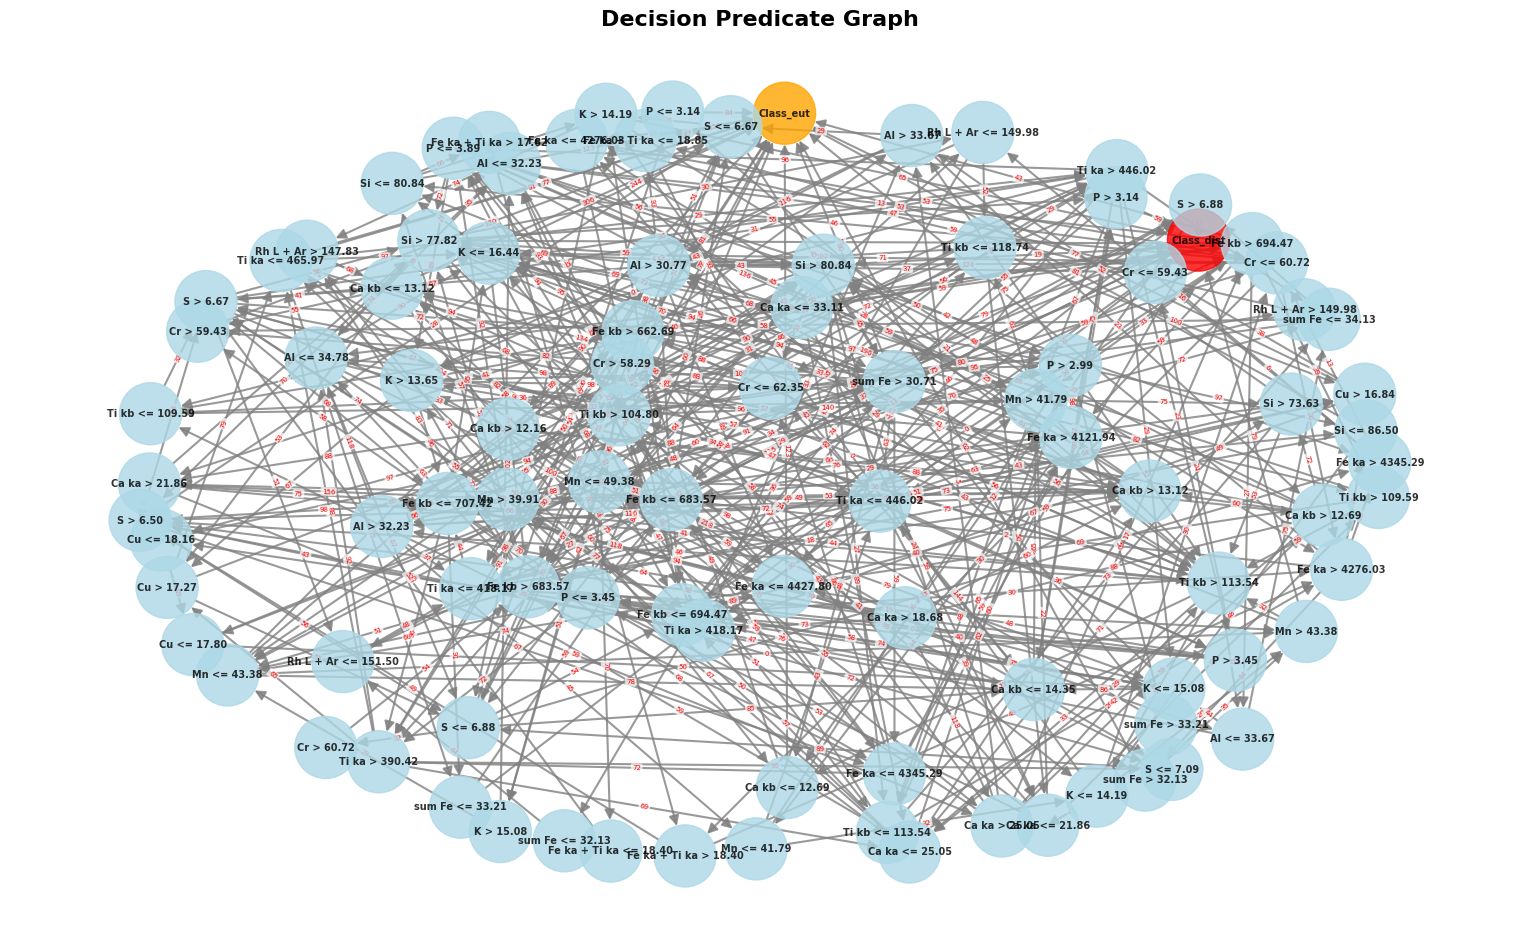

In [141]:
# Plotando o grafo final
import matplotlib.pyplot as plt
import networkx as nx

DG = graphs_by_seed[1]  # usando o grafo da semente 42 como exemplo

# Layout hierárquico simples
pos = nx.spring_layout(DG, k=10, iterations=100, seed=42)

# Cores dos nós
colors = []
for node in DG.nodes():
    node_type = DG.nodes[node].get('node_type', 'predicate')
    if node_type == 'root_predicate':
        colors.append('green')
    elif node_type == 'terminal':
        colors.append('orange' if DG.nodes[node].get('class_label') == 'eut' else 'red')
    else:
        colors.append('lightblue')

# Preparar labels das arestas (pesos)
edge_labels = {(u, v): f"{DG[u][v]['weight']:.0f}" for u, v in DG.edges()}

# Plotando
plt.figure(figsize=(15, 9))
nx.draw(DG, pos, 
        node_color=colors,
        node_size=2000,
        with_labels=True,
        font_size=7,
        font_weight='bold',
        arrows=True,
        arrowsize=15,
        edge_color='gray',
        width=1.5,
        alpha=0.8)

# Adicionar labels dos pesos nas arestas
nx.draw_networkx_edge_labels(DG, pos, 
                              edge_labels=edge_labels, 
                              font_size=5, 
                              font_color='red',
                              bbox=dict(boxstyle='round,pad=0.2', 
                                       facecolor='white', 
                                       edgecolor='none', 
                                       alpha=0.7))

plt.title('Decision Predicate Graph',
          fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [142]:
# establishing spectral cuts based on expert knowledge of XRF spectra
spectral_zones_full = [
('background1', 1.0, 1.33),
('Al', 1.34, 1.63),
('Si', 1.64, 1.86),
('background2', 1.87, 1.93),
('P', 1.94, 2.10),
('background3', 2.11, 2.19),
('S', 2.20, 2.44),
('background4', 2.45, 2.55),
('Rh L + Ar', 2.56, 3.10),
('background5', 3.11, 3.21),
('K', 3.22, 3.42),
('background6', 3.43, 3.53),
('Ca ka', 3.54, 3.82),
('Ca kb', 3.92, 4.14),
('background8', 4.15, 4.37),
('Ti ka', 4.38, 4.66),
('background9', 4.67, 4.75),
('Ti kb', 4.76, 5.12),
('Cr', 5.13, 5.77),
('Mn', 5.78, 6.02),
('background11', 6.03, 6.13),
('Fe ka', 6.14, 6.68),
('background12', 6.69, 6.80),
('Fe kb', 6.81, 7.30),
('background13', 7.31, 7.91),
('Cu', 7.92, 8.20),
('background14', 8.21, 10.69),
('Fe ka + Ti ka', 10.7, 11.14),
('background15', 11.15, 12.55),
('sum Fe' , 12.56, 13.1),
('background16', 13.11, 15.0)
]

In [169]:
vip_scores_df = pd.DataFrame({
    'energy' : plsda_results[4].T.index,
    'VIP_Score' : plsda_results[4].T.iloc[:,0].values
})
vip_scores_df = vip_scores_df.sort_values(by='VIP_Score', ascending=False).reset_index(drop=True)

# vamos gerar uma nova coluna em vip_scores_df com o nome da zona espectral correspondente de acordo com a lista spectral_cuts
energy_to_zone_vip = {} # dicionário para mapear energia para zona espectral
for zone_name, start, end in spectral_zones_full: # iterando sobre cada zona espectral (que tem nome, início e fim)
	for i in vip_scores_df['energy']: # iterando sobre cada valor de energia no vip_scores_df
		i_float = float(i)
		if start <= i_float <= end:
			energy_to_zone_vip[i] = zone_name
vip_scores_df['Zone'] = vip_scores_df['energy'].map(energy_to_zone_vip) # a funcao map funciona como um buscador que substitui os valores de 'energy' pelos valores correspondentes no dicionário energy_to_zone_vip
vip_scores_df

,energy,VIP_Score,Zone
0,3.7,7.506373,Ca ka
1,3.68,7.262794,Ca ka
2,3.72,7.095937,Ca ka
3,3.66,6.373020,Ca ka
4,3.74,5.982461,Ca ka
...,...,...,...
696,1.24,0.014053,background1
697,14.52,0.013660,background16
698,9.06,0.013577,background14
699,14.92,0.011689,background16


In [170]:
# vamos filtrar vip_scores_df para manter apenas as zonas espectrais únicas com maior VIP score
vip_scores_unique_df = vip_scores_df.drop_duplicates(subset=['Zone'], keep='first').reset_index(drop=True)
vip_scores_unique_df = vip_scores_unique_df.sort_values(by='VIP_Score', ascending=False).reset_index(drop=True)
vip_scores_unique_df

,energy,VIP_Score,Zone
0,3.7,7.506373,Ca ka
1,6.44,4.961940,Fe ka
2,5.9,2.235349,Mn
3,1.74,2.160608,Si
4,7.08,1.832155,Fe kb
5,4.54,1.822532,Ti ka
6,4.02,1.717719,Ca kb
7,1.48,1.160853,Al
8,3.3,1.029316,K
9,12.84,0.752731,sum Fe


In [171]:
reg_vet = pd.DataFrame(plsda_results[3].coef_, columns=plsda_results[3].feature_names_in_) # creating a DataFrame with regression coefficients
reg_vet = reg_vet.T
reg_vet.insert(0, 'energy', reg_vet.index) # adding energy column
reg_vet = reg_vet.reset_index(drop=True)
reg_vet.columns = ['energy', 'Reg_coef'] # renaming
reg_vet['Abs_Reg_coef'] = reg_vet['Reg_coef'].abs() # adding absolute value column
reg_vet = reg_vet.sort_values(by='Abs_Reg_coef', ascending=False).reset_index(drop=True) # sorting by absolute value

# gerando uma nova coluna em reg_vet com o nome da zona espectral correspondente de acordo com a lista spectral_cuts
energy_to_zone_reg = {} # dicionário para mapear energia para zona espectral
for zone_name, start, end in spectral_zones_full: # iterando sobre cada zona espectral (que tem nome, início e fim)
    for i in reg_vet['energy']: # iterando sobre cada valor de energia no reg_vet
        i_float = float(i)
        if start <= i_float <= end:
            energy_to_zone_reg[i] = zone_name
reg_vet['Zone'] = reg_vet['energy'].map(energy_to_zone_reg) # a funcao map funciona como um buscador que substitui os valores de 'energy' pelos valores correspondentes no dicionário energy_to_zone_reg
reg_vet

# vamos filtrar reg_vet para manter apenas as zonas espectrais únicas com maior valor absoluto do coeficiente de regressão
reg_vet_unique_df = reg_vet.drop_duplicates(subset=['Zone'], keep='first').reset_index(drop=True)
reg_vet_unique_df = reg_vet_unique_df.sort_values(by='Abs_Reg_coef', ascending=False).reset_index(drop=True)
reg_vet_unique_df

,energy,Reg_coef,Abs_Reg_coef,Zone
0,1.74,-0.048703,0.048703,Si
1,5.9,-0.046786,0.046786,Mn
2,3.7,-0.033770,0.033770,Ca ka
3,4.46,0.022996,0.022996,Ti ka
4,6.42,0.013572,0.013572,Fe ka
5,2.02,0.013222,0.013222,P
6,1.48,0.013022,0.013022,Al
7,4,-0.011633,0.011633,Ca kb
8,9.38,0.011608,0.011608,background14
9,3.3,-0.010813,0.010813,K


Using 148 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
100%|██████████| 148/148 [17:33<00:00,  7.12s/it]
C:\Users\Usuario\AppData\Local\Temp\ipykernel_29708\3279461856.py:7: FutureWarning:

The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.



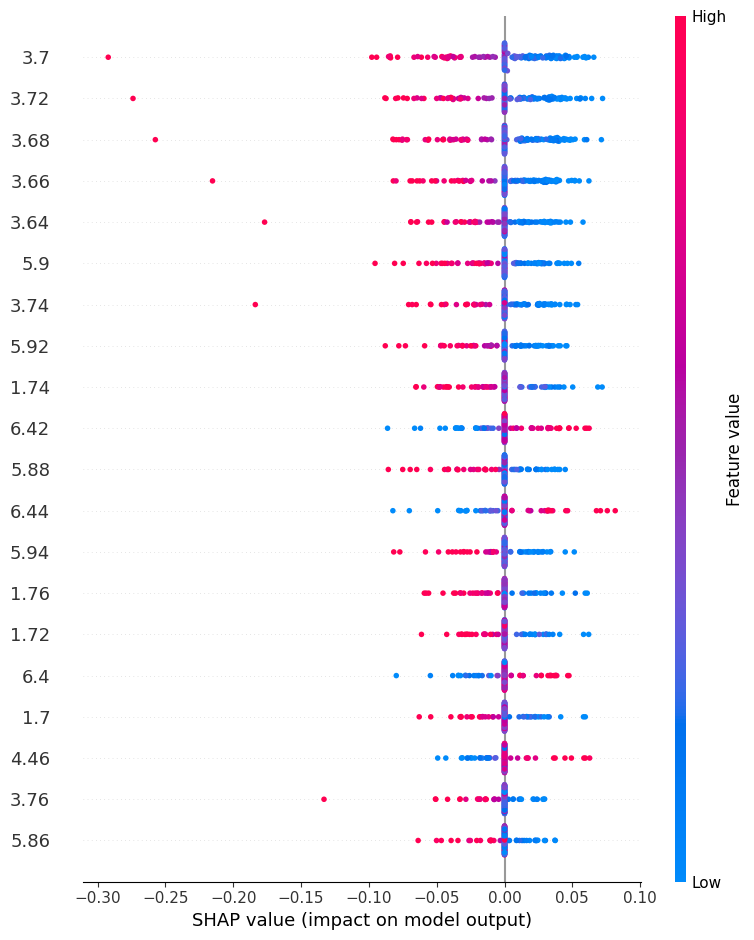

In [116]:
# vamos agora extrair as variaveis mais importantes atraves do método SHAP
import shap

# Para PLSRegression, usamos KernelExplainer porque não há explainer dedicado muito rápido
explainer_pls = shap.KernelExplainer(plsda_results[3].predict, Xcalclass_prep)
shap_values_pls = explainer_pls(Xcalclass_prep)
shap.summary_plot(shap_values_pls, Xcalclass_prep, feature_names=Xpredclass_prep.columns)

In [147]:
shap_global_importance = pd.DataFrame({
    'energy': Xpredclass_prep.columns,
    'Mean_Abs_SHAP': np.abs(shap_values_pls.values).mean(axis=0)}) # tomando a importancia global como a media dos valores absolutos dos valores SHAP para cada feature
shap_global_importance.sort_values(by='Mean_Abs_SHAP', ascending=False, inplace=True)

# vamos gerar uma nova coluna em shap_global_importance com o nome da zona espectral correspondente de acordo com a lista spectral_cuts
energy_to_zone_shap = {}
for zone_name, start, end in spectral_zones_full:
    for i in shap_global_importance['energy']:
        i_float = float(i)
        if start <= i_float <= end:
            energy_to_zone_shap[i] = zone_name
shap_global_importance['Zone'] = shap_global_importance['energy'].map(energy_to_zone_shap)
shap_global_importance

,energy,Mean_Abs_SHAP,Zone
135,3.7,0.027489,Ca ka
136,3.72,0.024141,Ca ka
134,3.68,0.023751,Ca ka
133,3.66,0.019377,Ca ka
132,3.64,0.014308,Ca ka
...,...,...,...
258,6.16,0.000000,Fe ka
259,6.18,0.000000,Fe ka
260,6.2,0.000000,Fe ka
261,6.22,0.000000,Fe ka


In [148]:
# agora vamos filtrar shap_global_importance para manter apenas as zonas espectrais únicas com maior SHAP score
shap_unique_df = shap_global_importance.drop_duplicates(subset=['Zone'], keep='first').reset_index(drop=True)
shap_unique_df = shap_unique_df.sort_values(by='Mean_Abs_SHAP', ascending=False).reset_index(drop=True)
shap_unique_df

,energy,Mean_Abs_SHAP,Zone
0,3.7,0.027489,Ca ka
1,5.9,0.013979,Mn
2,1.74,0.011243,Si
3,6.42,0.010746,Fe ka
4,4.46,0.005788,Ti ka
5,7.02,0.000251,Fe kb
6,4.04,0.000055,Ca kb
7,3.3,0.000047,K
8,2.02,0.000040,P
9,1.48,0.000012,Al


In [172]:
features_importance = pd.DataFrame({
    'Vip' : vip_scores_unique_df['Zone'].iloc[:15].values,
    'Reg_coef' : reg_vet_unique_df['Zone'].iloc[:15].values,
    'SHAP' : shap_unique_df['Zone'].iloc[:15].values})

for seed, lrc_unique_df in lrc_unique_by_seed.items():
    features_importance[f'LRC_Seed_{seed}'] = lrc_unique_df['Zone'].iloc[:15].values
features_importance

,Vip,Reg_coef,SHAP,LRC_Seed_0,LRC_Seed_1,LRC_Seed_2
0,Ca ka,Si,Ca ka,S,Al,Mn
1,Fe ka,Mn,Mn,Mn,Fe kb,Ca ka
2,Mn,Ca ka,Si,Fe ka,Ca kb,Ca kb
3,Si,Ti ka,Fe ka,Ti ka,sum Fe,Fe ka + Ti ka
4,Fe kb,Fe ka,Ti ka,Ti kb,Ca ka,K
5,Ti ka,P,Fe kb,Ca ka,Mn,Fe kb
6,Ca kb,Al,Ca kb,Fe kb,Ti ka,Si
7,Al,Ca kb,K,K,Ti kb,Rh L + Ar
8,K,background14,P,Ca kb,P,Ti ka
9,sum Fe,K,Al,Cr,S,Al


In [183]:
# utilizando o Rank-Biased Overlap (RBO) para comparar as listas de importância de características tendo o vip como referencia
# com p = 1 é rbo equivalente ao overlap simples (interseção sobre união) sem peso para posições iniciais
# quanto menor o p, mais peso é dado para as posições iniciais da lista (mais relevante para nosso caso)
import rbo

rbo_results = {}
reference_list = features_importance['Vip'].tolist()
methods = ['Reg_coef', 'SHAP'] + [f'LRC_Seed_{seed}' for seed in random_seeds]
for method in methods:
    compare_list = features_importance[method].tolist()
    score = rbo.RankingSimilarity(reference_list, compare_list).rbo(p=0.8, k=10) # o p=0.9 dá mais peso para as posições iniciais, k=10 limita a comparação às top 10 posições
    rbo_results[method] = score
rbo_results = pd.DataFrame(list(rbo_results.items()), columns=['Method', 'RBO_Score'])
rbo_results.insert(0, 'Reference', 'Vip')
rbo_results.sort_values(by='RBO_Score', ascending=False, inplace=True)
rbo_results

,Reference,Method,RBO_Score
1,Vip,SHAP,0.741920
0,Vip,Reg_coef,0.404005
4,Vip,LRC_Seed_2,0.393306
2,Vip,LRC_Seed_0,0.321544
3,Vip,LRC_Seed_1,0.175603


In [185]:
rbo_comparison = pd.DataFrame(columns=['Method_1', 'Method_2', 'RBO_Score'])
methods = features_importance.columns.tolist()
for i in range(len(methods)):
    for j in range(i + 1, len(methods)):
        method_1 = methods[i]
        method_2 = methods[j]
        list_1 = features_importance[method_1].tolist()
        list_2 = features_importance[method_2].tolist()
        rbo_score = rbo.RankingSimilarity(list_1, list_2).rbo(p=0.8, k=10)
        rbo_comparison = pd.concat([rbo_comparison, pd.DataFrame({
            'Method_1': [method_1],
            'Method_2': [method_2],
            'RBO_Score': [rbo_score]
        })], ignore_index=True)
rbo_comparison.sort_values(by='RBO_Score', ascending=False, inplace=True)
rbo_comparison

C:\Users\Usuario\AppData\Local\Temp\ipykernel_29708\3600406771.py:10: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



,Method_1,Method_2,RBO_Score
1,Vip,SHAP,0.741920
5,Reg_coef,SHAP,0.540497
11,SHAP,LRC_Seed_2,0.478548
0,Vip,Reg_coef,0.404005
4,Vip,LRC_Seed_2,0.393306
9,SHAP,LRC_Seed_0,0.380504
6,Reg_coef,LRC_Seed_0,0.352388
8,Reg_coef,LRC_Seed_2,0.352020
2,Vip,LRC_Seed_0,0.321544
13,LRC_Seed_0,LRC_Seed_2,0.268413


In [186]:
# calculando a mutual information relacionando cada variável espectral com a predição do modelo PLS-DA
from sklearn.feature_selection import mutual_info_regression
global_mi_scores = mutual_info_regression(Xcalclass_prep, 
                                    plsda_results[5].iloc[:,-1], # using the continuous predictions from LV=3
                                    discrete_features=False,
                                    random_state=42)
global_mi_scores_df = pd.DataFrame(global_mi_scores, index=Xcalclass_prep.columns, columns=['MI Score'])#.sort_values(by='MI Score', ascending=False)
global_mi_scores_df.plot()


In [187]:
plsda_results[4].T.plot()

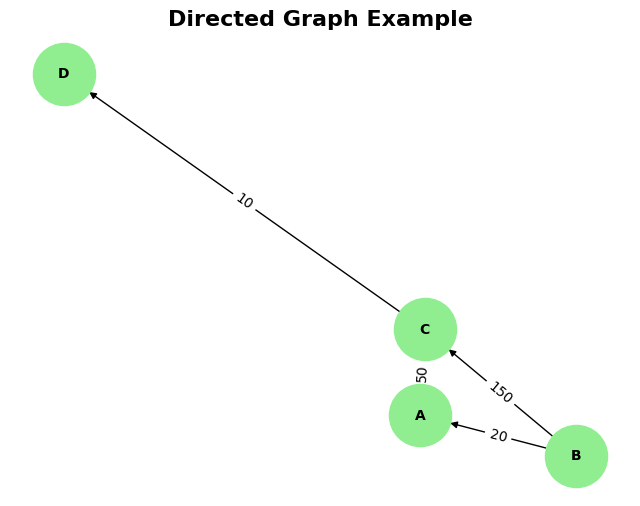

In [164]:
DG = nx.DiGraph()
DG.add_node("A")
DG.add_node("B")
DG.add_node("C")
DG.add_node("D")
DG.add_edge("B", "A", weight=20)
DG.add_edge("B", "C", weight=150)
DG.add_edge("A", "C", weight=50)
DG.add_edge("C", "D", weight=10)
 #plotar o grafo direcionado
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 6))
pos = nx.spring_layout(DG, seed=42)
nx.draw(DG, pos, with_labels=True, node_color='lightgreen', node_size=2000, font_size=10, font_weight='bold', arrows=True)
edge_labels = nx.get_edge_attributes(DG, 'weight')
nx.draw_networkx_edge_labels(DG, pos, edge_labels=edge_labels)
plt.title('Directed Graph Example', fontsize=16, fontweight='bold')
plt.show()